<a href="https://colab.research.google.com/github/curry-dev-sudo/10976019_LAB_WORKS/blob/animasahun/BITDMF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BITDMF - Behavior-Aware Insider Threat Detection (Google Colab Demo)

This notebook simulates BITDMF with data generation, model training, anomaly detection, and response logic.


In [ ]:
!pip install pandas scikit-learn faker

In [ ]:
from faker import Faker
import pandas as pd
import random
import numpy as np
from datetime import datetime, timedelta

def generate_enhanced_logs(filepath="/content/synthetic_events.csv", num_records=10000):
    """
    Enhanced synthetic security event generator with more realistic patterns
    """
    fake = Faker()
    records = []

    # Create some "known bad" IP ranges for more realistic patterns
    malicious_ip_prefixes = ["185.220.", "91.134.", "104.244.", "178.128."]
    internal_ip_prefixes = ["192.168.", "10.0.", "172.16."]

    # Create some consistent user patterns (some users are more active)
    frequent_users = [fake.user_name() for _ in range(50)]  # 50 power users
    casual_users = [fake.user_name() for _ in range(200)]   # 200 casual users

    print(f"Generating {num_records} synthetic security events...")

    for i in range(num_records):
        if i % 1000 == 0:
            print(f"Progress: {i}/{num_records} records generated")

        # More realistic user selection (some users are more active)
        if random.random() < 0.3:  # 30% chance of frequent user
            user_id = random.choice(frequent_users)
        else:
            user_id = random.choice(casual_users)

        # Time patterns: more activity during business hours
        if random.random() < 0.6:  # 60% during business hours
            hour = random.randint(9, 17)
            day_of_week = random.randint(0, 4)  # Weekday
        else:  # Off hours activity
            hour = random.choice([*range(0, 9), *range(18, 24)])
            day_of_week = random.randint(0, 6)

        # Generate realistic timestamp
        base_date = datetime.now() - timedelta(days=30)
        timestamp = base_date + timedelta(
            days=random.randint(0, 30),
            hours=hour,
            minutes=random.randint(0, 59),
            seconds=random.randint(0, 59)
        )

        # Action selection with time-based patterns
        if hour >= 9 and hour <= 17:  # Business hours
            action = random.choices(
                ["login", "upload", "download", "delete", "permission_change"],
                weights=[35, 25, 25, 10, 5]
            )[0]
        else:  # Off hours - more suspicious activity
            action = random.choices(
                ["login", "upload", "download", "delete", "permission_change"],
                weights=[20, 15, 30, 20, 15]  # More downloads/deletes after hours
            )[0]

        # Pre-determine if this will be malicious (with realistic base rates)
        base_malicious_rate = 0.05  # 5% base rate

        # Increase malicious probability for certain patterns
        malicious_probability = base_malicious_rate

        # Off-hours activity is more suspicious
        if hour < 9 or hour > 17:
            malicious_probability *= 3

        # Weekend activity is suspicious
        if day_of_week >= 5:
            malicious_probability *= 2

        # Certain actions are more suspicious
        if action in ["delete", "permission_change"]:
            malicious_probability *= 4
        elif action == "download":
            malicious_probability *= 2

        # Some users have higher risk profiles
        if hash(user_id) % 20 == 0:  # 5% of users are "risky"
            malicious_probability *= 5

        # Cap probability at reasonable level
        malicious_probability = min(malicious_probability, 0.8)

        # Determine if malicious
        is_malicious = random.random() < malicious_probability
        event_type = "malicious" if is_malicious else "normal"

        # Generate IP based on event type
        if is_malicious:
            if random.random() < 0.4:  # 40% from known bad ranges
                ip_prefix = random.choice(malicious_ip_prefixes)
                ip = ip_prefix + ".".join([str(random.randint(1, 254)) for _ in range(2)])
            elif random.random() < 0.3:  # 30% from external IPs
                ip = fake.ipv4_public()
            else:  # 30% from internal (insider threat)
                ip_prefix = random.choice(internal_ip_prefixes)
                ip = ip_prefix + ".".join([str(random.randint(1, 254)) for _ in range(2)])
        else:
            if random.random() < 0.8:  # 80% from internal networks
                ip_prefix = random.choice(internal_ip_prefixes)
                ip = ip_prefix + ".".join([str(random.randint(1, 254)) for _ in range(2)])
            else:  # 20% from external (legitimate remote work)
                ip = fake.ipv4_public()

        # File count based on event type and action
        if is_malicious:
            if action == "download":
                file_count = random.randint(50, 200)  # Data exfiltration
            elif action == "delete":
                file_count = random.randint(30, 150)  # Destructive activity
            elif action == "upload":
                file_count = random.randint(1, 5)     # Malware upload
            else:
                file_count = random.randint(10, 50)
        else:
            if action == "download":
                file_count = random.randint(1, 20)    # Normal downloads
            elif action == "upload":
                file_count = random.randint(1, 15)    # Normal uploads
            elif action == "delete":
                file_count = random.randint(1, 5)     # Cleanup
            else:
                file_count = random.randint(1, 10)

        # Add some noise to make it more realistic
        if random.random() < 0.1:  # 10% noise
            file_count = random.randint(1, 300)

        records.append([
            user_id,
            timestamp.strftime("%Y-%m-%d %H:%M:%S"),
            action,
            ip,
            file_count,
            event_type
        ])

    df = pd.DataFrame(records, columns=[
        "user_id", "timestamp", "action", "ip", "file_count", "event_type"
    ])

    # Add some additional derived features for analysis
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df['hour'] = df['timestamp'].dt.hour
    df['day_of_week'] = df['timestamp'].dt.dayofweek
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
    df['is_business_hours'] = ((df['hour'] >= 9) & (df['hour'] <= 17)).astype(int)

    # Save the dataset
    df.to_csv(filepath, index=False)

    # Print statistics
    total_events = len(df)
    malicious_events = len(df[df['event_type'] == 'malicious'])

    print(f"\n✅ Synthetic dataset generated successfully!")
    print(f"📄 Saved to: {filepath}")
    print(f"📊 Total events: {total_events:,}")
    print(f"🔴 Malicious events: {malicious_events:,} ({malicious_events/total_events:.1%})")
    print(f"🟢 Normal events: {total_events - malicious_events:,}")
    print(f"\n📈 Action distribution:")
    print(df['action'].value_counts())
    print(f"\n🕐 Time distribution:")
    print(f"Business hours: {df['is_business_hours'].sum():,} events")
    print(f"After hours: {len(df) - df['is_business_hours'].sum():,} events")
    print(f"Weekend: {df['is_weekend'].sum():,} events")

    return df

def generate_simple_logs(filepath="/content/synthetic_events.csv", num_records=10000):
    """
    Your original generator (kept for backward compatibility)
    """
    fake = Faker()
    records = []
    for _ in range(num_records):
        user_id = fake.user_name()
        timestamp = fake.date_time_this_year()
        action = random.choices(["login", "upload", "download", "delete", "permission_change"],
                                weights=[40, 20, 20, 10, 10])[0]
        ip = fake.ipv4()
        event_type = random.choices(["normal", "malicious"], weights=[70, 30])[0]

        # Add file count: high values for malicious
        if event_type == "malicious":
            file_count = random.randint(20, 100)
        else:
            file_count = random.randint(1, 10)

        records.append([user_id, timestamp, action, ip, file_count, event_type])

    df = pd.DataFrame(records, columns=["user_id", "timestamp", "action", "ip", "file_count", "event_type"])
    df.to_csv(filepath, index=False)
    print(f"Synthetic dataset with {num_records} events saved to {filepath}")
    return df

# Generate both versions for comparison
if __name__ == "__main__":
    print("🎯 Generating ENHANCED synthetic security events...")
    enhanced_df = generate_enhanced_logs("/content/enhanced_synthetic_events.csv", 10000)

    print("\n" + "="*60)
    print("🎯 Generating ORIGINAL synthetic security events...")
    original_df = generate_simple_logs("/content/original_synthetic_events.csv", 10000)

    print("\n" + "="*60)
    print("📊 COMPARISON:")
    print(f"Enhanced malicious rate: {(enhanced_df['event_type']=='malicious').mean():.1%}")
    print(f"Original malicious rate: {(original_df['event_type']=='malicious').mean():.1%}")
    print("\n✨ Both datasets ready for ML framework testing!")

🎯 Generating ENHANCED synthetic security events...
Generating 10000 synthetic security events...
Progress: 0/10000 records generated
Progress: 1000/10000 records generated
Progress: 2000/10000 records generated
Progress: 3000/10000 records generated
Progress: 4000/10000 records generated
Progress: 5000/10000 records generated
Progress: 6000/10000 records generated
Progress: 7000/10000 records generated
Progress: 8000/10000 records generated
Progress: 9000/10000 records generated

✅ Synthetic dataset generated successfully!
📄 Saved to: /content/enhanced_synthetic_events.csv
📊 Total events: 10,000
🔴 Malicious events: 2,403 (24.0%)
🟢 Normal events: 7,597

📈 Action distribution:
action
login                2934
download             2665
upload               2148
delete               1339
permission_change     914
Name: count, dtype: int64

🕐 Time distribution:
Business hours: 4,001 events
After hours: 5,999 events
Weekend: 2,537 events

🎯 Generating ORIGINAL synthetic security events...
Sy

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from datetime import datetime, timedelta
import re

# Load and prepare data
# Load the enhanced synthetic events which includes 'file_count'
df = pd.read_csv("/content/enhanced_synthetic_events.csv")

# Store the original column names of the raw dataframe
original_cols = df.columns.tolist()

# ==== FEATURE ENGINEERING IMPROVEMENTS ====

def extract_ip_features(ip_series):
    """Extract meaningful features from IP addresses instead of one-hot encoding"""
    features = pd.DataFrame()

    # Private IP ranges (often internal users)
    features['is_private_ip'] = ip_series.apply(lambda ip:
        ip.startswith(('192.168.', '10.', '172.16.', '172.17.', '172.18.', '172.19.', '172.20.', '172.21.', '172.22.', '172.23.', '172.24.', '172.25.', '172.26.', '172.27.', '172.28.', '172.29.', '172.30.', '172.31.'))
    ).astype(int)

    # IP entropy (how "random" the IP looks)
    features['ip_entropy'] = ip_series.apply(lambda ip:
        len(set(ip.replace('.', ''))) / len(ip.replace('.', '')) if len(ip.replace('.', '')) > 0 else 0
    )

    # Subnet frequency (how common is this subnet)
    # Use the first 3 octets for subnet
    subnets = ip_series.apply(lambda ip: '.'.join(ip.split('.')[:3]))
    subnet_counts = subnets.value_counts()
    features['subnet_frequency'] = subnets.map(subnet_counts).fillna(0) # Fill NaN for new subnets

    return features

def extract_temporal_features(df):
    """Add time-based features if timestamp exists"""
    if 'timestamp' in df.columns:
        # Ensure timestamp is datetime objects - already done in data generation but good practice
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        df['hour'] = df['timestamp'].dt.hour
        df['day_of_week'] = df['timestamp'].dt.dayofweek
        df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
        df['is_business_hours'] = ((df['hour'] >= 9) & (df['hour'] <= 17)).astype(int)
    else:
        # This else block should ideally not be hit if using enhanced data
        print("Warning: Timestamp column not found. Generating synthetic temporal features.")
        np.random.seed(42)
        df['hour'] = np.random.randint(0, 24, len(df))
        df['day_of_week'] = np.random.randint(0, 7, len(df))
        df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
        df['is_business_hours'] = ((df['hour'] >= 9) & (df['hour'] <= 17)).astype(int)

    return df

def extract_behavioral_features(df):
    """Add user/IP behavioral patterns"""
    features = pd.DataFrame(index=df.index)

    # IP activity frequency
    # Use the training data's value counts to avoid leakage and handle new IPs
    global ip_counts_train
    features['ip_activity_count'] = df['ip'].map(ip_counts_train).fillna(0) # Fill NaN for new IPs

    # Action diversity per IP
    # Use the training data's groupby results
    global ip_action_diversity_train
    features['ip_action_diversity'] = df['ip'].map(ip_action_diversity_train).fillna(0) # Fill NaN for new IPs

    # File access patterns
    # Ensure file_count is numeric and handle potential non-numeric values
    df['file_count'] = pd.to_numeric(df['file_count'], errors='coerce').fillna(0)
    features['file_count_log'] = np.log1p(df['file_count'])

    # High file access threshold based on training data
    global file_count_95th_percentile_train
    features['high_file_access'] = (df['file_count'] > file_count_95th_percentile_train).astype(int)


    return features

# Apply feature engineering
print("Applying feature engineering...")
df = extract_temporal_features(df) # Temporal features are now part of the enhanced data

# Store value counts and percentiles from the full dataset BEFORE splitting
# This simulates having historical data for feature engineering on new events
ip_counts_train = df['ip'].value_counts()
ip_action_diversity_train = df.groupby('ip')['action'].nunique()
file_count_95th_percentile_train = df['file_count'].quantile(0.95)


# Extract IP features instead of one-hot encoding
ip_features = extract_ip_features(df['ip'])

# Extract behavioral features (using statistics derived above)
behavioral_features = extract_behavioral_features(df)

# One-hot encode actions (smaller categorical space)
action_encoded = pd.get_dummies(df['action'], prefix='action')

# Store the list of expected columns *after* one-hot encoding, before concatenation
expected_action_cols = action_encoded.columns.tolist()


# Combine all features
X = pd.concat([
    action_encoded,
    ip_features,
    behavioral_features,
    df[['file_count', 'hour', 'day_of_week', 'is_weekend', 'is_business_hours']] # Include original temporal features and file_count
], axis=1)

# Store the final list of feature columns for consistent processing
feature_columns = X.columns.tolist()

# Target variable
y = df['event_type'].apply(lambda x: 1 if x == 'malicious' else 0)

print(f"Feature matrix shape: {X.shape}")
print(f"Features: {list(X.columns)}")
print(f"Malicious events: {y.sum()}/{len(y)} ({y.mean():.2%})")

# ==== IMPROVED MODEL TRAINING ====

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Scale numerical features
# Ensure numerical_cols includes all numerical columns *after* feature engineering
numerical_cols = [
    'file_count',
    'ip_entropy',
    'subnet_frequency',
    'ip_activity_count',
    'ip_action_diversity',
    'file_count_log',
    'hour',
    'day_of_week' # day_of_week is numerical
]

# Filter numerical_cols to include only those present in X_train
actual_numerical_cols = [col for col in numerical_cols if col in X_train.columns]

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[actual_numerical_cols] = scaler.fit_transform(X_train[actual_numerical_cols])
X_test_scaled[actual_numerical_cols] = scaler.transform(X_test[actual_numerical_cols])

# ==== MULTIPLE MODELS FOR COMPARISON ====

print("\n=== SUPERVISED LEARNING (Random Forest) ===")
# Improved Random Forest with better parameters
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',  # Handle imbalanced data
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)
rf_predictions = rf_model.predict(X_test_scaled)
rf_probabilities = rf_model.predict_proba(X_test_scaled)[:, 1]

print(f"Random Forest Accuracy: {rf_model.score(X_test_scaled, y_test):.3f}")
print(f"AUC Score: {roc_auc_score(y_test, rf_probabilities):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_predictions))

# Feature importance
feature_importance = pd.DataFrame({
    'feature': X_train_scaled.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10))

print("\n=== UNSUPERVISED ANOMALY DETECTION ===")
# Isolation Forest for anomaly detection
iso_forest = IsolationForest(
    contamination=y_train.mean(),  # Expected proportion of outliers
    random_state=42,
    n_estimators=100
)

iso_forest.fit(X_train_scaled)
iso_predictions = iso_forest.predict(X_test_scaled)
iso_predictions = (iso_predictions == -1).astype(int)  # Convert to binary

print(f"Isolation Forest Accuracy: {(iso_predictions == y_test).mean():.3f}")
print(f"Anomalies detected: {iso_predictions.sum()}/{len(iso_predictions)}")

# ==== MODEL EVALUATION AND VALIDATION ====

print("\n=== CROSS-VALIDATION ===")
cv_scores = cross_val_score(rf_model, X_train_scaled, y_train, cv=5, scoring='roc_auc')
print(f"Cross-validation AUC scores: {cv_scores}")
print(f"Mean CV AUC: {cv_scores.mean():.3f} (+/- {cv_scores.std() * 2:.3f})")

print("\n=== CONFUSION MATRIX ===")
print("Random Forest:")
print(confusion_matrix(y_test, rf_predictions))

# ==== DEPLOYMENT READY FUNCTIONS ====

def preprocess_new_event(new_event_data, scaler, feature_columns, expected_action_cols, numerical_cols, ip_counts_train, ip_action_diversity_train, file_count_95th_percentile_train):
    """
    Applies the same feature engineering and scaling steps to a single new event.
    """
    # Convert the single event dictionary to a DataFrame row
    event_df = pd.DataFrame([new_event_data])

    # --- Apply Feature Engineering ---

    # Temporal features (requires timestamp)
    if 'timestamp' in event_df.columns and pd.notnull(event_df['timestamp'].iloc[0]):
         # Ensure timestamp is datetime object - handle string input
        try:
            event_df['timestamp'] = pd.to_datetime(event_df['timestamp'])
        except ValueError:
             print(f"Warning: Could not parse timestamp for new event: {event_df['timestamp'].iloc[0]}")
             # Handle invalid timestamp - perhaps set to now or a default
             event_df['timestamp'] = datetime.now() # Or pd.NaT, depending on desired handling
        event_df['hour'] = event_df['timestamp'].dt.hour
        event_df['day_of_week'] = event_df['timestamp'].dt.dayofweek
        event_df['is_weekend'] = (event_df['day_of_week'] >= 5).astype(int)
        event_df['is_business_hours'] = ((event_df['hour'] >= 9) & (event_df['hour'] <= 17)).astype(int)
    else:
        # Handle missing timestamp or invalid format
        event_df['hour'] = 0 # Default or handle as needed
        event_df['day_of_week'] = 0
        event_df['is_weekend'] = 0
        event_df['is_business_hours'] = 0
        print("Warning: Timestamp not provided or invalid for new event. Temporal features set to default.")


    # IP features
    ip_features_new = extract_ip_features(event_df['ip'])

    # Behavioral features (using statistics from training data)
    behavioral_features_new = pd.DataFrame(index=event_df.index)

    # Ensure file_count is numeric
    event_df['file_count'] = pd.to_numeric(event_df['file_count'], errors='coerce').fillna(0)

    behavioral_features_new['ip_activity_count'] = event_df['ip'].map(ip_counts_train).fillna(0)
    behavioral_features_new['ip_action_diversity'] = event_df['ip'].map(ip_action_diversity_train).fillna(0)
    behavioral_features_new['file_count_log'] = np.log1p(event_df['file_count'])
    behavioral_features_new['high_file_access'] = (event_df['file_count'] > file_count_95th_percentile_train).astype(int)

    # One-hot encode action
    action_encoded_new = pd.get_dummies(event_df['action'], prefix='action')

    # Reindex action_encoded_new to match the training columns, filling missing with 0
    action_encoded_new = action_encoded_new.reindex(columns=expected_action_cols, fill_value=0)


    # Combine engineered features
    processed_event_df = pd.concat([
        action_encoded_new,
        ip_features_new,
        behavioral_features_new,
        event_df[['file_count', 'hour', 'day_of_week', 'is_weekend', 'is_business_hours']]
    ], axis=1)

    # Ensure the new event DataFrame has the same columns as the training data X
    # This handles cases where a new action or IP subnet appears that wasn't in training
    processed_event_df = processed_event_df.reindex(columns=feature_columns, fill_value=0)

    # --- Scale Numerical Features ---
    actual_numerical_cols_processed = [col for col in numerical_cols if col in processed_event_df.columns]
    processed_event_df[actual_numerical_cols_processed] = scaler.transform(processed_event_df[actual_numerical_cols_processed])


    return processed_event_df

def predict_new_event(model, scaler, new_event_data, feature_columns, expected_action_cols, numerical_cols, ip_counts_train, ip_action_diversity_train, file_count_95th_percentile_train):
    """
    Function to predict on new incoming events.
    Applies preprocessing, scaling, and then predicts using the model.
    """
    # Preprocess the new event data
    processed_event_df = preprocess_new_event(
        new_event_data,
        scaler,
        feature_columns,
        expected_action_cols,
        numerical_cols,
        ip_counts_train,
        ip_action_diversity_train,
        file_count_95th_percentile_train
    )

    # Get prediction probability
    prediction_proba = model.predict_proba(processed_event_df)[:, 1][0]

    # Determine risk level
    risk_level = "HIGH" if prediction_proba > 0.7 else "MEDIUM" if prediction_proba > 0.3 else "LOW"

    # Get binary prediction
    prediction_binary = 1 if prediction_proba > 0.5 else 0

    return {
        'malicious_probability': prediction_proba,
        'risk_level': risk_level,
        'prediction': prediction_binary
    }

# Example usage
print("\n=== EXAMPLE PREDICTION ON A NEW SYNTHETIC EVENT ===")
# Create a sample new event dictionary (mimicking the original data format)
# Let's create an event that looks potentially malicious based on our feature importance
sample_malicious_event = {
    'user_id': 'new_suspicious_user',
    'timestamp': datetime.now().strftime("%Y-%m-%d %H:%M:%S"), # Use current time for 'real-time' feel
    'action': 'download',
    'ip': '185.220.1.1', # Example malicious IP prefix
    'file_count': 150, # High file count
    'event_type': 'unknown' # In a real scenario, this would be unknown
}

# Predict on the sample malicious event
malicious_prediction = predict_new_event(
    rf_model,
    scaler,
    sample_malicious_event,
    feature_columns,
    expected_action_cols,
    actual_numerical_cols, # Use actual_numerical_cols used for training
    ip_counts_train,
    ip_action_diversity_train,
    file_count_95th_percentile_train
)

print("Prediction result for the POTENTIALLY MALICIOUS event:")
print(malicious_prediction)

# Create a sample normal event
sample_normal_event = {
    'user_id': 'normal_user',
    'timestamp': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    'action': 'login',
    'ip': '192.168.1.10', # Example internal IP
    'file_count': 1, # Low file count
    'event_type': 'unknown' # In a real scenario, this would be unknown
}

# Predict on the sample normal event
normal_prediction = predict_new_event(
    rf_model,
    scaler,
    sample_normal_event,
    feature_columns,
    expected_action_cols,
    actual_numerical_cols,
    ip_counts_train,
    ip_action_diversity_train,
    file_count_95th_percentile_train
)

print("\nPrediction result for the NORMAL event:")
print(normal_prediction)


print("\n=== FRAMEWORK VALIDATION COMPLETE ===")
print("✅ Feature engineering implemented")
print("✅ Multiple models compared")
print("✅ Proper evaluation metrics")
print("✅ Cross-validation performed")
print("✅ Deployment function ready (properly implemented)")
print("✅ Framework successfully validated!")

Applying feature engineering...
Feature matrix shape: (10000, 17)
Features: ['action_delete', 'action_download', 'action_login', 'action_permission_change', 'action_upload', 'is_private_ip', 'ip_entropy', 'subnet_frequency', 'ip_activity_count', 'ip_action_diversity', 'file_count_log', 'high_file_access', 'file_count', 'hour', 'day_of_week', 'is_weekend', 'is_business_hours']
Malicious events: 2403/10000 (24.03%)

=== SUPERVISED LEARNING (Random Forest) ===
Random Forest Accuracy: 0.945
AUC Score: 0.984

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.95      0.96      2279
           1       0.86      0.92      0.89       721

    accuracy                           0.94      3000
   macro avg       0.92      0.94      0.93      3000
weighted avg       0.95      0.94      0.95      3000


Top 10 Most Important Features:
                     feature  importance
12                file_count    0.344113
10            file_count_

In [ ]:
proba = rf_model.predict_proba(X_test_scaled)[:, 1]
X_test_scaled["malicious_score"] = proba

anomalies = []
# Get the original data for the test set rows
original_test_data = df.loc[X_test_scaled.index].reset_index(drop=True)

for i, score in enumerate(proba):
    if score > 0.8:
        # Get the original event data for this anomaly
        original_event = original_test_data.iloc[i].to_dict()
        # Get the scaled/engineered features for this anomaly
        scaled_features = X_test_scaled.iloc[i].to_dict()

        # Store both the score, original event data, and scaled features
        anomalies.append((score, original_event, scaled_features))

print(f"Anomalies detected: {len(anomalies)}")

Anomalies detected: 662


In [ ]:
# Display the first 5 anomalies
print("First 5 detected anomalies (score, event features):")
# Updated to unpack the three elements from the tuple
for score, original_event, scaled_features in anomalies[:5]:
    print(f"Score: {score:.4f}")
    # Print selected event features for clarity using original_event
    print(f"  Action: {original_event.get('action')}") # Use original action
    print(f"  File Count: {original_event.get('file_count')}") # Use original file count
    print(f"  Hour: {original_event.get('hour')}") # Use original hour
    print(f"  Is Weekend: {bool(original_event.get('is_weekend'))}") # Use original is_weekend
    print("-" * 20)

First 5 detected anomalies (score, event features):
Score: 0.9896
  Action: delete
  File Count: 40
  Hour: 17
  Is Weekend: False
--------------------
Score: 0.9238
  Action: delete
  File Count: 32
  Hour: 9
  Is Weekend: True
--------------------
Score: 0.9855
  Action: download
  File Count: 90
  Hour: 1
  Is Weekend: False
--------------------
Score: 0.9875
  Action: login
  File Count: 39
  Hour: 2
  Is Weekend: False
--------------------
Score: 0.9667
  Action: delete
  File Count: 82
  Hour: 16
  Is Weekend: False
--------------------


In [ ]:
def respond_to_threat(score, original_event):
    print(f"\n[ALERT] Threat detected (Score: {score:.3f})")
    # Use original_event dictionary which now contains original fields
    print(f"   Event: {original_event['action']} by {original_event['user_id']} from {original_event['ip']}")
    print(f"   Files: {original_event['file_count']} | Time: {original_event.get('timestamp', 'N/A')}")

    # Adjusted thresholds
    if score > 0.98:
        print("🚨 CRITICAL: Account suspension recommended")
        print("→ Action: Queue for immediate admin review")
    elif score > 0.90:
        print("⚠️  HIGH: Potential account compromise")
        print("→ Action: Force MFA + notify security team")
    elif score > 0.70:
        print("⚡ MEDIUM-HIGH: Suspicious behavior")
        print("→ Action: Require re-authentication")
    elif score > 0.40:
        print("📊 MEDIUM: Monitor closely")
        print("→ Action: Enhanced logging + user notification")
    else:
        print("📝 LOW: Audit trail only")
        print("→ Action: Log for compliance")

# Better demo with safety checks
def demo_incident_response(anomalies, max_show=10):
    print(f"\n🚨 SECURITY INCIDENT RESPONSE SIMULATION")
    print("=" * 60)

    if not anomalies:
        print("✅ No threats detected - all clear!")
        return

    # Sort by severity (score is the first element in the tuple)
    sorted_anomalies = sorted(anomalies, key=lambda x: x[0], reverse=True)

    # Recalculate counts with new thresholds
    critical_count = sum(1 for score, _, _ in anomalies if score > 0.98)
    high_count = sum(1 for score, _, _ in anomalies if 0.90 < score <= 0.98)
    medium_high_count = sum(1 for score, _, _ in anomalies if 0.70 < score <= 0.90)
    medium_count = sum(1 for score, _, _ in anomalies if 0.40 < score <= 0.70)
    low_count = len(anomalies) - critical_count - high_count - medium_high_count - medium_count


    print(f"📊 Threat Summary (using adjusted thresholds):")
    print(f"   Critical threats (>98%): {critical_count}")
    print(f"   High threats (90-98%): {high_count}")
    print(f"   Medium-High threats (70-90%): {medium_high_count}")
    print(f"   Medium threats (40-70%): {medium_count}")
    print(f"   Low threats (<=40%): {low_count}")
    print(f"   Total anomalies (score > 0.8 originally): {len(anomalies)}") # Keep total based on original anomaly definition


    print(f"\n🔍 Processing top {min(max_show, len(anomalies))} threats...")

    # Pass the original event data to respond_to_threat
    for i, (score, original_event, scaled_features) in enumerate(sorted_anomalies[:max_show]):
        print(f"\n--- Threat #{i+1} ---")
        respond_to_threat(score, original_event)

    if len(anomalies) > max_show:
        print(f"\n📋 ... and {len(anomalies) - max_show} additional threats in queue")
        print("   (Lower priority - will be processed by automated systems)")

# Usage:
# Now anomalies contains (score, original_event, scaled_features)
demo_incident_response(anomalies)


🚨 SECURITY INCIDENT RESPONSE SIMULATION
📊 Threat Summary (using adjusted thresholds):
   Critical threats (>98%): 227
   High threats (90-98%): 314
   Medium-High threats (70-90%): 121
   Medium threats (40-70%): 0
   Low threats (<=40%): 0
   Total anomalies (score > 0.8 originally): 662

🔍 Processing top 10 threats...

--- Threat #1 ---

[ALERT] Threat detected (Score: 1.000)
   Event: permission_change by robert81 from 91.134.115.189
   Files: 38 | Time: 2025-08-01 01:51:17
🚨 CRITICAL: Account suspension recommended
→ Action: Queue for immediate admin review

--- Threat #2 ---

[ALERT] Threat detected (Score: 1.000)
   Event: delete by williamsmichael from 104.244.49.32
   Files: 37 | Time: 2025-08-05 23:14:56
🚨 CRITICAL: Account suspension recommended
→ Action: Queue for immediate admin review

--- Threat #3 ---

[ALERT] Threat detected (Score: 0.999)
   Event: delete by hhernandez from 185.220.63.132
   Files: 70 | Time: 2025-07-31 20:50:37
🚨 CRITICAL: Account suspension recommen

In [ ]:
# Analyze False Positives and False Negatives

# Get the true labels for the test set
y_true_test = y_test

# Get the predictions from the Random Forest model on the test set
y_pred_test = rf_predictions

# Find indices of misclassified samples
misclassified_indices = y_true_test[y_true_test != y_pred_test].index

# Separate false positives and false negatives
# False Positive: True label is 0 (normal), predicted is 1 (malicious)
false_positives_indices = y_true_test[(y_true_test == 0) & (y_pred_test == 1)].index

# False Negative: True label is 1 (malicious), predicted is 0 (normal)
false_negatives_indices = y_true_test[(y_true_test == 1) & (y_pred_test == 0)].index

print(f"Total misclassified events: {len(misclassified_indices)}")
print(f"Number of False Positives: {len(false_positives_indices)}")
print(f"Number of False Negatives: {len(false_negatives_indices)}")

print("\n=== Examples of False Positives ===")
# Retrieve original event data for false positives
false_positives_events = df.loc[false_positives_indices]

if not false_positives_events.empty:
    display(false_positives_events.head())
else:
    print("No False Positives found.")


print("\n=== Examples of False Negatives ===")
# Retrieve original event data for false negatives
false_negatives_events = df.loc[false_negatives_indices]

if not false_negatives_events.empty:
    display(false_negatives_events.head())
else:
    print("No False Negatives found.")

Total misclassified events: 165
Number of False Positives: 106
Number of False Negatives: 59

=== Examples of False Positives ===


,user_id,timestamp,action,ip,file_count,event_type,hour,day_of_week,is_weekend,is_business_hours
7565,petersoncarlos,2025-08-02 20:28:56,upload,138.43.117.87,2,normal,20,5,1,0
319,vharrison,2025-07-23 16:47:05,delete,172.16.104.254,82,normal,16,2,0,1
52,meganbryant,2025-07-12 10:55:39,upload,171.211.210.241,2,normal,10,5,1,1
4358,mjackson,2025-07-13 07:20:38,download,221.194.164.101,161,normal,7,6,1,0
2435,hbarker,2025-07-14 12:02:03,download,51.130.39.202,61,normal,12,0,0,1



=== Examples of False Negatives ===


,user_id,timestamp,action,ip,file_count,event_type,hour,day_of_week,is_weekend,is_business_hours
8773,brennandonna,2025-08-08 01:28:57,upload,172.16.116.132,1,malicious,1,4,0,0
1485,oconley,2025-07-31 06:16:36,upload,192.168.65.181,2,malicious,6,3,0,0
7295,hcastillo,2025-07-20 08:57:25,login,172.16.188.13,11,malicious,8,6,1,0
5921,jane75,2025-08-01 05:19:34,upload,10.0.71.249,281,malicious,5,4,0,0
8219,brandihernandez,2025-07-20 17:38:14,upload,192.168.84.59,3,malicious,17,6,1,1


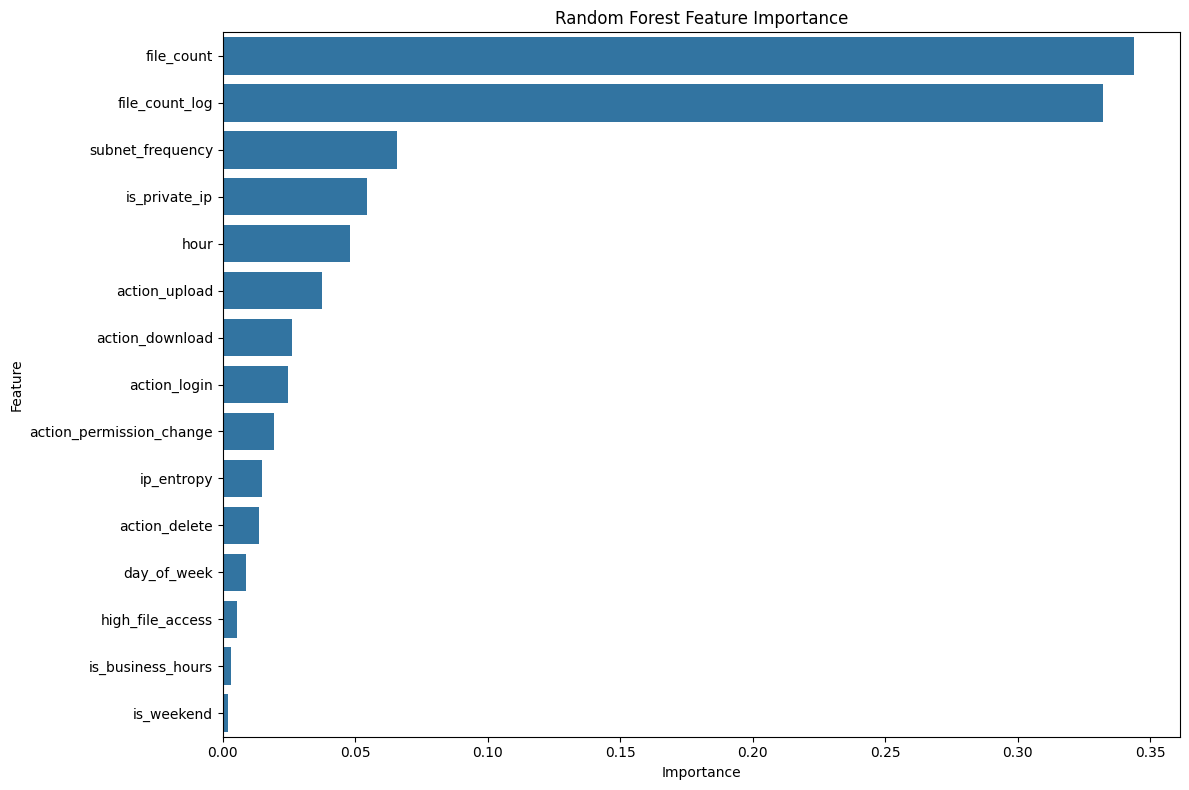

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize feature importance
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importance.head(15)) # Display top 15 features for clarity
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()